# Stage 7 - Interpret a severe price event

**Input:** the realised Day-Ahead price (`data/day_ahead_prices.csv`), the Stage 4 Day-Ahead
residual per strategy (`data/residual_da.csv`), the Stage 5 imbalance result
(`data/imbalance.csv`), the futures positions/prices needed to reconstruct a per-interval cost
(`data/hedge_positions.csv`, `data/selected_products.csv`, `data/hpfc.csv`), and the Stage 5/6
annual summaries (`data/final_costs.csv`) for context

**Output:** the event-window data behind the discussion (`data/severe_event.csv`)

**Task:** identify a relevant high-price event in the 2024 Day-Ahead data, show the Day-Ahead
price, customer load, hedge, and residual exposure through it, compare how the three strategies
were exposed and how the event affected procurement cost, add a simple sensitivity, and answer the
brief's liquidity/continuity question - without assuming one expensive event is automatically
fatal. This is an interpretation exercise: no new optimization, just Stage 1-6's already-computed
load, hedge, and cost results read through one window.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

DATA = "../data"
DT = 0.25
C_CAL, C_GRAN, C_UNHEDGED = "#DD8452", "#4C72B0", "#8172B3"
STRATEGIES = ["UNHEDGED", "COARSE_CAL", "GRANULAR"]
COLORS = {"UNHEDGED": C_UNHEDGED, "COARSE_CAL": C_CAL, "GRANULAR": C_GRAN}
HEDGE_COL = {"UNHEDGED": "hedge_unhedged_mwh", "COARSE_CAL": "hedge_coarse_cal_mwh", "GRANULAR": "hedge_granular_mwh"}

residual    = pd.read_csv(f"{DATA}/residual_da.csv")
imbalance   = pd.read_csv(f"{DATA}/imbalance.csv")
positions   = pd.read_csv(f"{DATA}/hedge_positions.csv")
selected    = pd.read_csv(f"{DATA}/selected_products.csv")
hpfc        = pd.read_csv(f"{DATA}/hpfc.csv")[["timestamp_utc", "period", "is_peak"]]
final_costs = pd.read_csv(f"{DATA}/final_costs.csv").set_index("strategy").reindex(STRATEGIES)

df = residual.merge(hpfc, on="timestamp_utc", validate="one_to_one")
df = df.merge(imbalance[["timestamp_utc", "total_actual_mwh", "imbalance_volume_mwh", "imbalance_price_eur_mwh"]],
              on="timestamp_utc", validate="one_to_one")
df["t_local"] = pd.to_datetime(df["timestamp_utc"], utc=True).dt.tz_convert("Europe/Berlin")
assert df.isna().sum().sum() == 0

print("merged grid:", df.shape, "-> Stage 4 residual x HPFC block/Peak grid x Stage 5 imbalance")
print("annual mean Day-Ahead price:", f"{df['day_ahead_price_eur_mwh'].mean():.2f} EUR/MWh")
final_costs

merged grid: (35136, 15) -> Stage 4 residual x HPFC block/Peak grid x Stage 5 imbalance
annual mean Day-Ahead price: 78.51 EUR/MWh


,C_futures_EUR,C_residual_DA_EUR,C_forecast_EUR,C_imb_EUR,Premium_imb_EUR,C_final_EUR,saving_vs_UNHEDGED_EUR
strategy,,,,,,,
UNHEDGED,0.00,"3,506,703.99","3,506,703.99","30,503.84","13,589.24","3,537,207.83",0.00
COARSE_CAL,"3,493,701.73","-42,735.09","3,450,966.64","30,503.84","13,589.24","3,481,470.48","55,737.35"
GRANULAR,"3,493,705.92","-42,198.57","3,451,507.34","30,503.84","13,589.24","3,482,011.18","55,196.65"


## 1. Identify the event

Rank 2024 by daily mean and daily maximum Day-Ahead price to find the standout stretch.

In [2]:
daily = df.set_index("t_local")["day_ahead_price_eur_mwh"].resample("D").agg(["mean", "max"])
top_days = daily.sort_values("mean", ascending=False).head(8)
top_days.index = top_days.index.strftime("%Y-%m-%d")
top_days.columns = ["daily_mean_EUR_MWh", "daily_max_EUR_MWh"]
top_days

,daily_mean_EUR_MWh,daily_max_EUR_MWh
t_local,,
2024-12-12,395.34,936.28
2024-12-11,266.54,445.08
2024-11-06,231.09,820.11
2024-12-04,182.47,287.76
2024-12-13,178.47,284.21
2024-11-12,166.12,317.89
2024-11-05,164.78,505.31
2024-11-07,159.62,408.26


**12 December 2024 is the clear outlier**: a daily mean of 395 EUR/MWh (annual mean: 78.51
EUR/MWh) and a peak of 936.28 EUR/MWh at 17:00-18:00 local time - a low-wind, low-solar "Dunkelflaute"
spell. It is not an isolated single hour: prices already ramp up on 10-11 Dec and only ease back to
normal on 14 Dec, so the event is analysed as the four-day window **10-13 December 2024** (96 hours,
384 quarter-hours - about 1.1% of the year).

In [3]:
EVENT_START = pd.Timestamp("2024-12-10", tz="Europe/Berlin")
EVENT_END   = pd.Timestamp("2024-12-14", tz="Europe/Berlin")   # exclusive
ev = df[(df["t_local"] >= EVENT_START) & (df["t_local"] < EVENT_END)].copy()

print(f"event window: {EVENT_START.date()} to {EVENT_END.date()} (exclusive) - {len(ev)} quarter-hours = {len(ev)/96:.0f} days")
print(f"event Day-Ahead price: mean {ev['day_ahead_price_eur_mwh'].mean():.2f} EUR/MWh, "
      f"peak {ev['day_ahead_price_eur_mwh'].max():.2f} EUR/MWh "
      f"({ev['day_ahead_price_eur_mwh'].max() / df['day_ahead_price_eur_mwh'].mean():.1f}x the annual mean)")
print(f"event actual load: {ev['total_actual_mwh'].sum():,.0f} MWh "
      f"({100 * ev['total_actual_mwh'].sum() / df['total_actual_mwh'].sum():.2f}% of annual load)")

event window: 2024-12-10 to 2024-12-14 (exclusive) - 384 quarter-hours = 4 days
event Day-Ahead price: mean 247.57 EUR/MWh, peak 936.28 EUR/MWh (11.9x the annual mean)
event actual load: 549 MWh (1.27% of annual load)


## 2. Price, load, hedge, and residual exposure through the event

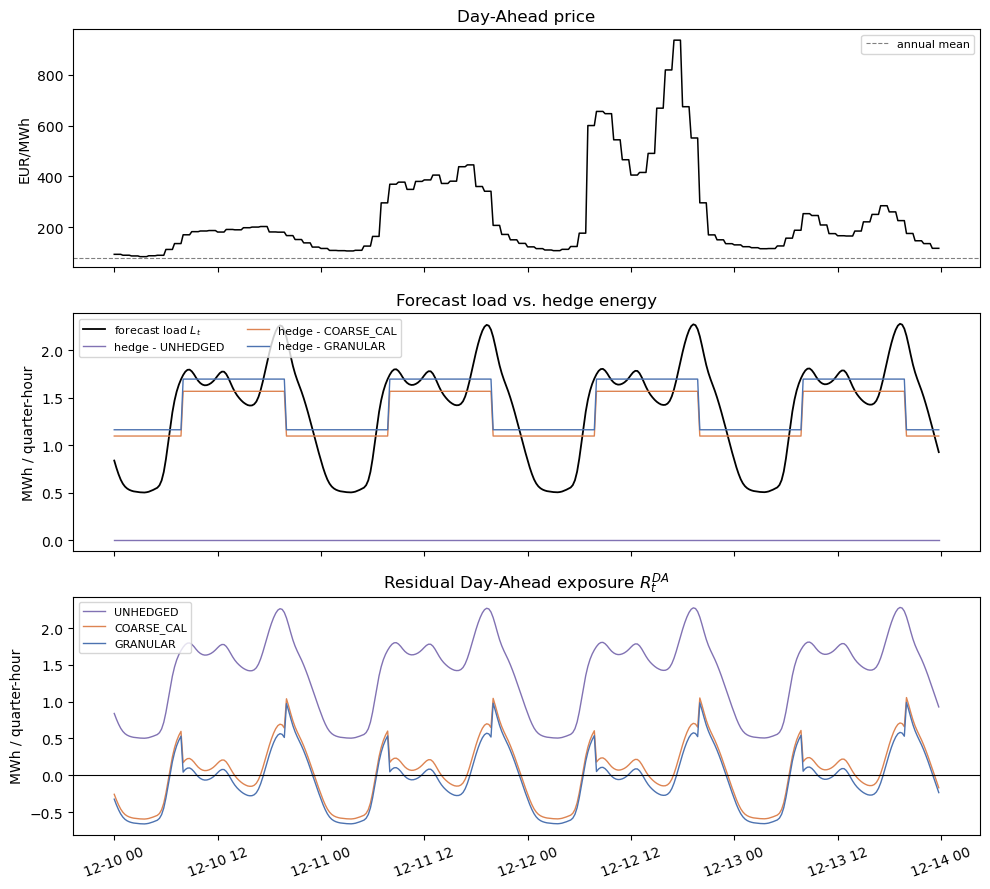

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

axes[0].plot(ev["t_local"], ev["day_ahead_price_eur_mwh"], color="black", lw=1.1)
axes[0].axhline(df["day_ahead_price_eur_mwh"].mean(), color="grey", lw=0.8, ls="--", label="annual mean")
axes[0].set_ylabel("EUR/MWh"); axes[0].set_title("Day-Ahead price"); axes[0].legend(fontsize=8)

axes[1].plot(ev["t_local"], ev["load_mwh"], color="black", lw=1.3, label="forecast load $L_t$")
for strategy in STRATEGIES:
    axes[1].plot(ev["t_local"], ev[HEDGE_COL[strategy]], color=COLORS[strategy], lw=1, label=f"hedge - {strategy}")
axes[1].set_ylabel("MWh / quarter-hour"); axes[1].set_title("Forecast load vs. hedge energy"); axes[1].legend(fontsize=8, ncol=2)

for strategy in STRATEGIES:
    axes[2].plot(ev["t_local"], ev[f"R_DA_{strategy}"], color=COLORS[strategy], lw=1, label=strategy)
axes[2].axhline(0, color="black", lw=0.8)
axes[2].set_ylabel("MWh / quarter-hour"); axes[2].set_title(r"Residual Day-Ahead exposure $R_t^{DA}$")
axes[2].legend(fontsize=8); axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout(); plt.show()

**Comment.** The price panel shows the ramp-up on 10-11 Dec and the extreme evening spike on 12
Dec, right in the winter Peak window (17:00-18:00) where heating demand and low wind coincide -
exactly the timing the HPFC's implied Off-Peak/Peak split (Stage 2) was built to price, but the
*level* on this one evening is far outside anything the 2019-2022 historical shape could anticipate.
The middle panel shows why exposure differs so much by strategy: `UNHEDGED`'s hedge is flat zero, so
its residual (bottom panel, purple) *is* the load - it tracks every evening peak and morning ramp in
full. `COARSE_CAL`'s hedge (orange) is a flat annual level that sits below the load's evening peaks,
leaving a small but real positive residual exactly when prices are highest. `GRANULAR`'s hedge
(blue) is closest to the load's shape and, on this particular event, briefly runs *above* it during
the evening peak - a small negative residual, i.e. surplus hedge energy that gets sold back into the
spike rather than bought at it.

## 3. Cost impact by strategy

Reconstruct the same quarter-hourly cost decomposition used in Stage 6
($cost_t = futures\_cost_t + R_t^{DA} P_t^{DA} + I_t P_t^{imb}$) and reconcile it against Stage 5's
annual `C_final` before restricting it to the event window.

In [5]:
price_base = selected[selected["load_type"] == "BASE"].set_index("delivery_period")["price_eur_mwh"]
price_peak = selected[selected["load_type"] == "PEAK"].set_index("delivery_period")["price_eur_mwh"]

cal_pos = positions[positions["strategy"] == "COARSE_CAL"].iloc[0]
df["futures_cost_COARSE_CAL"] = DT * (cal_pos["x_base_MW"] * price_base["CAL"]
                                       + cal_pos["x_peak_MW"] * price_peak["CAL"] * df["is_peak"])
gran_pos = positions[positions["strategy"] == "GRANULAR"].set_index("block")
df["x_base_g"] = df["period"].map(gran_pos["x_base_MW"])
df["x_peak_g"] = df["period"].map(gran_pos["x_peak_MW"])
df["futures_cost_GRANULAR"] = DT * (df["x_base_g"] * df["period"].map(price_base)
                                     + df["x_peak_g"] * df["period"].map(price_peak) * df["is_peak"])
df["futures_cost_UNHEDGED"] = 0.0
for s in STRATEGIES:
    df[f"total_cost_{s}"] = (df[f"futures_cost_{s}"] + df[f"R_DA_{s}"] * df["day_ahead_price_eur_mwh"]
                              + df["imbalance_volume_mwh"] * df["imbalance_price_eur_mwh"])
    assert np.isclose(df[f"total_cost_{s}"].sum(), final_costs.loc[s, "C_final_EUR"], atol=1e-3)
print("Reconciled: the reconstructed series again sums to Stage 5's C_final for every strategy.")

ev = df[(df["t_local"] >= EVENT_START) & (df["t_local"] < EVENT_END)].copy()
ev_imb_cost = (ev["imbalance_volume_mwh"] * ev["imbalance_price_eur_mwh"]).sum()

event_summary = pd.DataFrame({
    "event_futures_cost_EUR":     {s: ev[f"futures_cost_{s}"].sum() for s in STRATEGIES},
    "event_DA_residual_cost_EUR": {s: (ev[f"R_DA_{s}"] * ev["day_ahead_price_eur_mwh"]).sum() for s in STRATEGIES},
    "event_imbalance_cost_EUR":   ev_imb_cost,
    "event_total_cost_EUR":       {s: ev[f"total_cost_{s}"].sum() for s in STRATEGIES},
    "event_abs_residual_MWh":     {s: ev[f"R_DA_{s}"].abs().sum() for s in STRATEGIES},
}).reindex(STRATEGIES)
event_summary["event_cost_pct_of_annual_C_final"] = 100 * event_summary["event_total_cost_EUR"] / final_costs["C_final_EUR"]
event_summary["event_abs_residual_pct_of_annual"] = 100 * event_summary["event_abs_residual_MWh"] / final_costs.index.map(
    lambda s: df[f"R_DA_{s}"].abs().sum())

print(f"\nevent imbalance cost (identical for every strategy): {ev_imb_cost:,.0f} EUR "
      f"= {100 * ev_imb_cost / final_costs.loc['UNHEDGED', 'C_imb_EUR']:.1f}% of the *full year's* C_imb, "
      f"packed into 1.1% of the year's days.")
event_summary

Reconciled: the reconstructed series again sums to Stage 5's C_final for every strategy.

event imbalance cost (identical for every strategy): 9,277 EUR = 30.4% of the *full year's* C_imb, packed into 1.1% of the year's days.


,event_futures_cost_EUR,event_DA_residual_cost_EUR,event_imbalance_cost_EUR,event_total_cost_EUR,event_abs_residual_MWh,event_cost_pct_of_annual_C_final,event_abs_residual_pct_of_annual
UNHEDGED,0.00,"148,798.78","9,277.17","158,075.95",529.14,4.47,1.23
COARSE_CAL,"40,408.38","12,838.97","9,277.17","62,524.51",130.68,1.80,1.02
GRANULAR,"59,094.59","2,364.90","9,277.17","70,736.66",125.54,2.03,1.05


**Reading the table.**

- **`UNHEDGED` bears the event almost entirely live.** Its 158,076 EUR event cost is 4.5% of its
  *annual* procurement cost, concentrated into ~1.1% of the year's days - about four times its normal
  daily run-rate share - and 99% of that (148,799 EUR) is Day-Ahead residual cost on the *full* load,
  because there is no hedge to absorb any of it.
- **The hedged strategies' event-driven (price-live) cost is far smaller.** `COARSE_CAL`'s residual
  cost during the event is 12,839 EUR and `GRANULAR`'s is only 2,365 EUR - both a small fraction of
  `UNHEDGED`'s, because most of their load in these quarter-hours was already covered by futures
  bought in September 2023, long before this price was known.
- **But total event cost does not rank the same way `COARSE_CAL` < `GRANULAR`**, because
  `GRANULAR`'s Q4 block was priced at the winter futures premium (101-134 EUR/MWh, Stage 2) - it
  already "pre-paid" more for December exposure than `COARSE_CAL`'s flat annual rate. That extra
  59,095 EUR of `GRANULAR`'s event-window cost is a **fixed price agreed a year earlier**, not new
  risk created by this event; the residual line above is the fairer measure of *live* exposure, and
  on that measure `GRANULAR` is the best protected of the three.
- **The imbalance settlement is identical for all three strategies** (Section 4 in Stage 5) and this
  one four-day event alone accounts for **30% of the entire year's** imbalance cost - a striking
  concentration of forecast-error risk that no futures choice touches at all.

In [6]:
peak_t = ev.loc[ev["day_ahead_price_eur_mwh"].idxmax(), "t_local"]
peak_row = df.loc[df["t_local"] == peak_t].iloc[0]

peak_table = pd.DataFrame({
    "load_MWh": {s: peak_row["load_mwh"] for s in STRATEGIES},
    "hedge_MWh": {s: peak_row[HEDGE_COL[s]] for s in STRATEGIES},
    "R_DA_MWh": {s: peak_row[f"R_DA_{s}"] for s in STRATEGIES},
}).reindex(STRATEGIES)
print(f"single worst quarter-hour: {peak_t}  (Day-Ahead price {peak_row['day_ahead_price_eur_mwh']:.2f} EUR/MWh, "
      f"actual load {peak_row['total_actual_mwh']:.3f} MWh, imbalance {peak_row['imbalance_volume_mwh']:+.3f} MWh "
      f"@ {peak_row['imbalance_price_eur_mwh']:.2f} EUR/MWh)")
peak_table

single worst quarter-hour: 2024-12-12 17:00:00+01:00  (Day-Ahead price 936.28 EUR/MWh, actual load 1.678 MWh, imbalance +0.089 MWh @ 90.05 EUR/MWh)


,load_MWh,hedge_MWh,R_DA_MWh
UNHEDGED,1.59,0.00,1.59
COARSE_CAL,1.59,1.57,0.02
GRANULAR,1.59,1.70,-0.11


**The single worst quarter-hour (12 Dec, 17:00, 936.28 EUR/MWh)** makes the pattern concrete:
`UNHEDGED` buys its full 1.589 MWh at 936.28 EUR/MWh (about 1,488 EUR for 15 minutes, versus ~127 EUR
at the annual average price - an ~11x hit). `COARSE_CAL` is almost perfectly matched (0.020 MWh
residual). `GRANULAR` is actually net *long* at this exact interval (-0.109 MWh) - it would sell the
small surplus back into the spike, a windfall from being over-hedged rather than a loss. That is a
feature of *this* year's realised shape, not a designed guarantee: a different evening load shape
during the next such event could just as easily have left `GRANULAR` net short instead.

## 4. Simple sensitivity (optional)

Two "what if" checks, using only arithmetic on data already computed - no new optimization or
simulation, as the brief allows.

In [7]:
sensitivity = pd.DataFrame({
    "event_DA_residual_cost_EUR (actual)":      event_summary["event_DA_residual_cost_EUR"],
    "if event prices were 2x (residual unchanged)": event_summary["event_DA_residual_cost_EUR"] * 2,
}).reindex(STRATEGIES)
sensitivity.loc["ALL (imbalance)"] = [ev_imb_cost, ev_imb_cost * 2]
print("Price sensitivity (Day-Ahead residual cost only; futures cost is fixed and unaffected):")
display(sensitivity)

EVENT_START_8D = pd.Timestamp("2024-12-06", tz="Europe/Berlin")
ev8 = df[(df["t_local"] >= EVENT_START_8D) & (df["t_local"] < EVENT_END)]
duration_sensitivity = pd.DataFrame({
    "4-day window (10-13 Dec, actual)": {s: ev[f"total_cost_{s}"].sum() for s in STRATEGIES},
    "8-day window (06-13 Dec, actual)": {s: ev8[f"total_cost_{s}"].sum() for s in STRATEGIES},
}).reindex(STRATEGIES)
print("\nDuration sensitivity (real data for the wider window that already includes the 10-11 Dec ramp-up):")
duration_sensitivity

Price sensitivity (Day-Ahead residual cost only; futures cost is fixed and unaffected):


,event_DA_residual_cost_EUR (actual),if event prices were 2x (residual unchanged)
UNHEDGED,"148,798.78","297,597.56"
COARSE_CAL,"12,838.97","25,677.93"
GRANULAR,"2,364.90","4,729.81"
ALL (imbalance),"9,277.17","18,554.34"



Duration sensitivity (real data for the wider window that already includes the 10-11 Dec ramp-up):


,"4-day window (10-13 Dec, actual)","8-day window (06-13 Dec, actual)"
UNHEDGED,"158,075.95","208,382.00"
COARSE_CAL,"62,524.51","106,292.77"
GRANULAR,"70,736.66","127,236.34"


Doubling the event's prices roughly doubles the *residual* cost line for every strategy - it
scales linearly because volumes are held fixed (no demand response modelled). Widening the window to
the full 8-day ramp-up-to-cooldown period (real data, not an extrapolation) roughly doubles the total
event cost as well, for all three strategies alike - a *longer* event is proportionally worse
regardless of which strategy is used, because none of the three strategies do anything to shorten a
weather-driven price event.

## 5. Liquidity, continuity, and the risk that remains

**Could an unhedged event like this threaten liquidity or the ability to keep serving customers?**
On its own, this specific event is a material but bounded shock for `UNHEDGED`: 158,076 EUR (or
~208,000 EUR over the realistic 8-day window) against a 3.54m EUR annual procurement book - roughly
six weeks of average spend compressed into four to eight days, and settled on Day-Ahead's short
cash cycle while most customers are presumably on fixed-price annual contracts that cannot be
re-priced mid-year. That is a real, immediate cash-flow stress, but it is not, by itself, evidence
that the company would become insolvent or unable to serve customers - that conclusion would depend
on facts this case study does not model: the size of the company's cash and credit buffers, how many
such events occur in a year, and whether they cluster. What the data *does* support is that the size
scales with duration (Section 4) and, most importantly, with whether the load is hedged at all: the
hedged strategies faced 2,365-12,839 EUR of *live* price exposure over the same four days, two
orders of magnitude less than `UNHEDGED`'s 148,799 EUR - the futures hedge converts an
open-ended spot exposure into a small, bounded one for exactly this kind of event.

**Which risks remain even with the hedge.**

- **Residual Day-Ahead exposure never reaches zero.** Even `GRANULAR`'s well-shaped hedge still had
  ~126 MWh open across these four days: this year it happened to net out favourably at the single
  worst hour, but a different load shape during the next severe event could leave any strategy net
  *short* exactly when prices spike.
- **Imbalance risk is completely untouched by the hedge choice.** The identical 9,277 EUR imbalance
  cost during this one event (30% of the *entire year's* imbalance settlement) is pure forecast
  error, exposed under every strategy including the best-shaped one - only better forecasting or
  demand flexibility would reduce it, not a different futures mix (Stage 5).
- **Basis/shape risk in the HPFC.** The hedge and the HPFC that valued it were both built from a
  2019-2022 historical price shape (Stage 2); by construction, that history cannot anticipate a
  specific future Dunkelflaute, so the *quality* of protection during any one severe event is not
  guaranteed by the optimization in Stage 3.
- **Margin/collateral risk is not modelled here at all.** In practice, extreme volatility like 10-13
  Dec often triggers variation-margin calls on open futures and balancing positions, due within
  hours - a faster-moving liquidity risk than the settlement cost itself, and one this simplified,
  cost-accounting exercise does not capture for any of the three strategies.

## 6. Save the event data

In [8]:
event_cols = ["timestamp_utc", "day_ahead_price_eur_mwh", "load_mwh"] + list(HEDGE_COL.values()) \
    + [f"R_DA_{s}" for s in STRATEGIES] + ["total_actual_mwh", "imbalance_volume_mwh", "imbalance_price_eur_mwh"] \
    + [f"total_cost_{s}" for s in STRATEGIES]
severe_event = df[(df["t_local"] >= EVENT_START) & (df["t_local"] < EVENT_END)][event_cols]
severe_event.to_csv(f"{DATA}/severe_event.csv", index=False)
print("saved:", f"{DATA}/severe_event.csv", severe_event.shape)
severe_event.head()

saved: ../data/severe_event.csv (384, 15)


,timestamp_utc,day_ahead_price_eur_mwh,load_mwh,hedge_unhedged_mwh,hedge_coarse_cal_mwh,hedge_granular_mwh,R_DA_UNHEDGED,R_DA_COARSE_CAL,R_DA_GRANULAR,total_actual_mwh,imbalance_volume_mwh,imbalance_price_eur_mwh,total_cost_UNHEDGED,total_cost_COARSE_CAL,total_cost_GRANULAR
33024,2024-12-09T23:00:00Z,92.85,0.84,0.00,1.10,1.16,0.84,-0.26,-0.32,0.87,0.03,34.76,78.84,61.72,88.78
33025,2024-12-09T23:15:00Z,92.85,0.76,0.00,1.10,1.16,0.76,-0.34,-0.40,0.78,0.02,18.62,71.18,54.06,81.12
33026,2024-12-09T23:30:00Z,92.85,0.70,0.00,1.10,1.16,0.70,-0.40,-0.47,0.71,0.02,-7.25,64.46,47.34,74.40
33027,2024-12-09T23:45:00Z,92.85,0.64,0.00,1.10,1.16,0.64,-0.46,-0.53,0.65,0.02,-22.52,58.92,41.80,68.86
33028,2024-12-10T00:00:00Z,89.33,0.60,0.00,1.10,1.16,0.60,-0.50,-0.57,0.61,0.01,30.91,53.63,40.38,67.67
